# Task 3.5 — Step-size strategy comparison

Сравнение стратегий выбора шага для градиентного спуска:
- `Constant`
- `Armijo` (backtracking)
- `Wolfe`

На двух задачах:
1. Квадратичная функция
2. ML-оракул (Log-Cosh + L2)


In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from src.optimization import gradient_descent
from src.oracles import QuadraticOracle, LogCoshL2Oracle

np.random.seed(42)


In [3]:
def run_gd(oracle, x0, line_search_options, tolerance=1e-8, max_iter=5000):
    x_star, msg, history = gradient_descent(
        oracle,
        x0,
        tolerance=tolerance,
        max_iter=max_iter,
        line_search_options=line_search_options,
        trace=True,
    )
    return x_star, msg, history


def rel_func_residual(history, f_star):
    f0 = history['func'][0]
    denom = max(abs(f0 - f_star), 1e-16)
    return np.array([(f - f_star) / denom for f in history['func']])


def rel_grad_sq(history):
    g = np.array(history['grad_norm'])
    g0_sq = max(g[0] ** 2, 1e-32)
    return (g ** 2) / g0_sq


def draw_curves(curves, title, ylabel):
    plt.figure(figsize=(8, 5))
    for name, y in curves.items():
        y_plot = np.maximum(y, 1e-16)
        plt.semilogy(np.arange(len(y_plot)), y_plot, label=name, linewidth=2)
    plt.xlabel('iteration')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, which='both', ls='--', alpha=0.35)
    plt.legend()
    plt.show()


def best_by_threshold(curves, thr=1e-6):
    best_name = None
    best_iter = None
    for name, y in curves.items():
        idx = np.where(y <= thr)[0]
        reached = int(idx[0]) if len(idx) else np.inf
        if best_iter is None or reached < best_iter:
            best_iter = reached
            best_name = name
    return best_name, best_iter


Quadratic | start #1
  Const c=1e-4     msg=iterations_exceeded    iters= 7000
  Const c=5e-4     msg=iterations_exceeded    iters= 7000
  Armijo c1=1e-4   msg=success                iters= 4728
  Armijo c1=1e-2   msg=success                iters= 4728
  Wolfe c2=0.1     msg=success                iters= 4022
  Wolfe c2=0.9     msg=success                iters= 2352


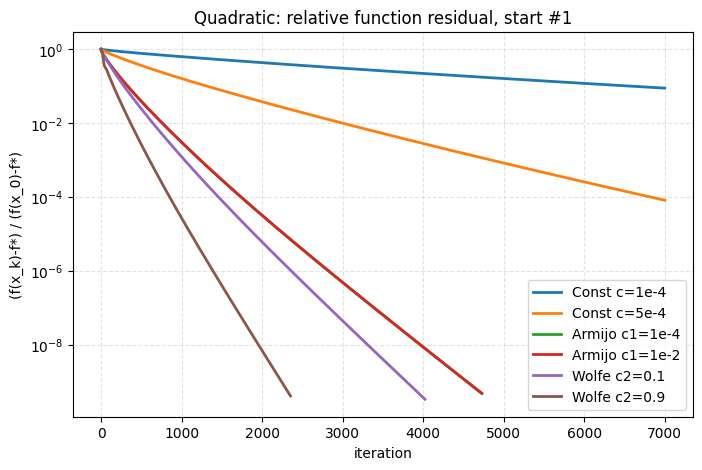

  Best by threshold 1e-8: Wolfe c2=0.9, iter=1955
----------------------------------------------------------------------
Quadratic | start #2
  Const c=1e-4     msg=iterations_exceeded    iters= 7000
  Const c=5e-4     msg=iterations_exceeded    iters= 7000
  Armijo c1=1e-4   msg=success                iters= 2399
  Armijo c1=1e-2   msg=success                iters= 2399
  Wolfe c2=0.1     msg=success                iters= 2479
  Wolfe c2=0.9     msg=success                iters= 1209


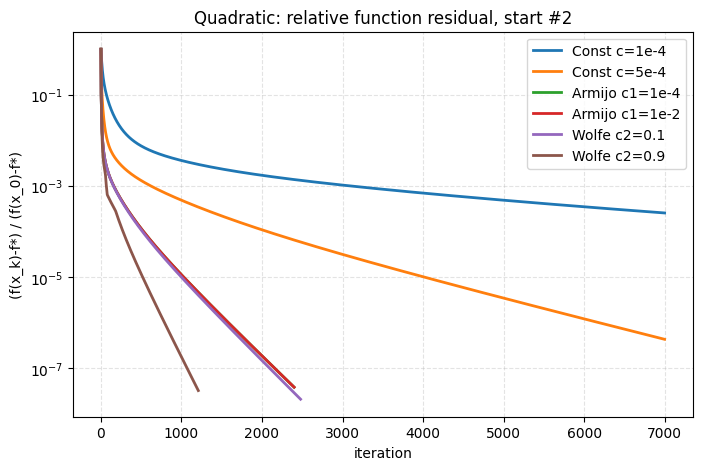

  Best by threshold 1e-8: Const c=1e-4, iter=inf
----------------------------------------------------------------------


In [4]:
n = 40
U = np.random.randn(n, n)
Q, _ = np.linalg.qr(U)

eigs = np.geomspace(1.0, 1e3, n)
A = Q.T @ np.diag(eigs) @ Q
b = np.random.randn(n)

quad_oracle = QuadraticOracle(A, b)

# Analytical optimum for quadratic
x_opt = np.linalg.solve(A, b)
f_star = quad_oracle.func(x_opt)

x0_quad_variants = [
    np.zeros(n),
    np.ones(n),
]

quad_strategies = {
    'Const c=1e-4': {'method': 'Constant', 'c': 1e-4},
    'Const c=5e-4': {'method': 'Constant', 'c': 5e-4},
    'Armijo c1=1e-4': {'method': 'Armijo', 'c1': 1e-4, 'alpha_0': 1.0},
    'Armijo c1=1e-2': {'method': 'Armijo', 'c1': 1e-2, 'alpha_0': 1.0},
    'Wolfe c2=0.1': {'method': 'Wolfe', 'c1': 1e-4, 'c2': 0.1},
    'Wolfe c2=0.9': {'method': 'Wolfe', 'c1': 1e-4, 'c2': 0.9},
}

for i, x0 in enumerate(x0_quad_variants, 1):
    curves = {}
    print(f'Quadratic | start #{i}')
    for name, ls in quad_strategies.items():
        x_star, msg, hist = run_gd(quad_oracle, x0, ls, tolerance=1e-10, max_iter=7000)
        curves[name] = rel_func_residual(hist, f_star)
        print(f'  {name:16s} msg={msg:22s} iters={len(hist["func"]) - 1:5d}')

    draw_curves(
        curves,
        title=f'Quadratic: relative function residual, start #{i}',
        ylabel='(f(x_k)-f*) / (f(x_0)-f*)',
    )

    best_name, best_iter = best_by_threshold(curves, thr=1e-8)
    print(f'  Best by threshold 1e-8: {best_name}, iter={best_iter}')
    print('-' * 70)


In [7]:
# a = curves['Armijo c1=1e-4']
# b = curves['Armijo c1=1e-2']

# m = min(len(a), len(b))
# print(np.allclose(a[:m], b[:m], rtol=1e-6, atol=1e-12))
# print('len(a)=', len(a), 'len(b)=', len(b))

ML (Log-Cosh) | start #1
  Const c=1e-3     msg=iterations_exceeded    iters= 5000, hit@1e-8=inf
  Const c=3e-3     msg=iterations_exceeded    iters= 5000, hit@1e-8=inf
  Armijo c1=1e-4   msg=success                iters=   15, hit@1e-8=15
  Armijo c1=1e-2   msg=success                iters=   15, hit@1e-8=15
  Wolfe c2=0.1     msg=success                iters=    9, hit@1e-8=9
  Wolfe c2=0.9     msg=success                iters=   11, hit@1e-8=11


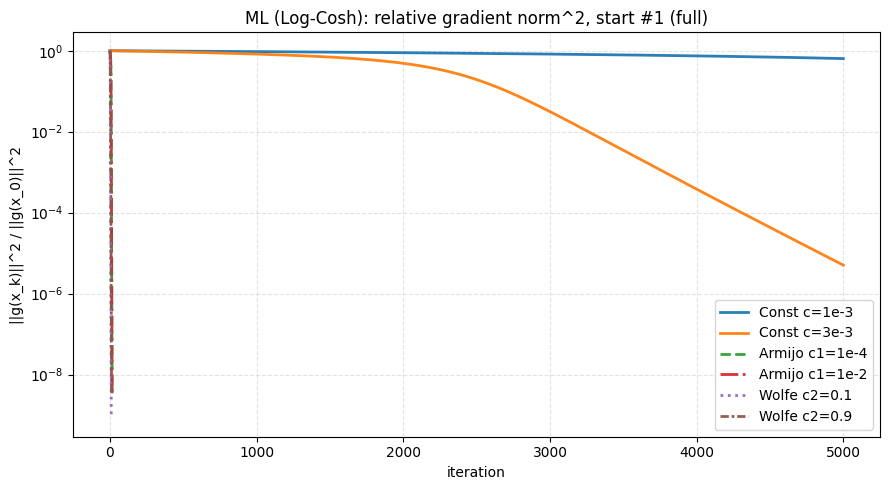

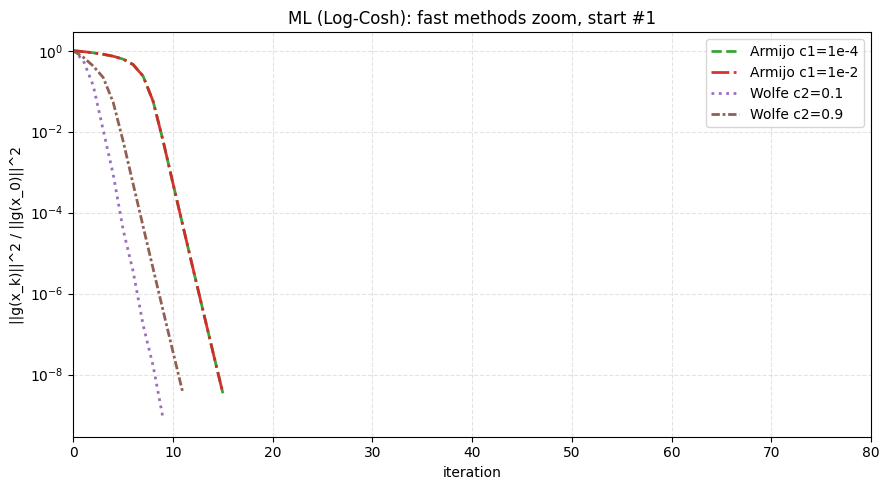

  Best by threshold 1e-8: Wolfe c2=0.1, iter=9
--------------------------------------------------------------------------------
ML (Log-Cosh) | start #2
  Const c=1e-3     msg=iterations_exceeded    iters= 5000, hit@1e-8=inf
  Const c=3e-3     msg=iterations_exceeded    iters= 5000, hit@1e-8=inf
  Armijo c1=1e-4   msg=success                iters=   24, hit@1e-8=24
  Armijo c1=1e-2   msg=success                iters=   24, hit@1e-8=24
  Wolfe c2=0.1     msg=success                iters=   10, hit@1e-8=10
  Wolfe c2=0.9     msg=success                iters=   13, hit@1e-8=13


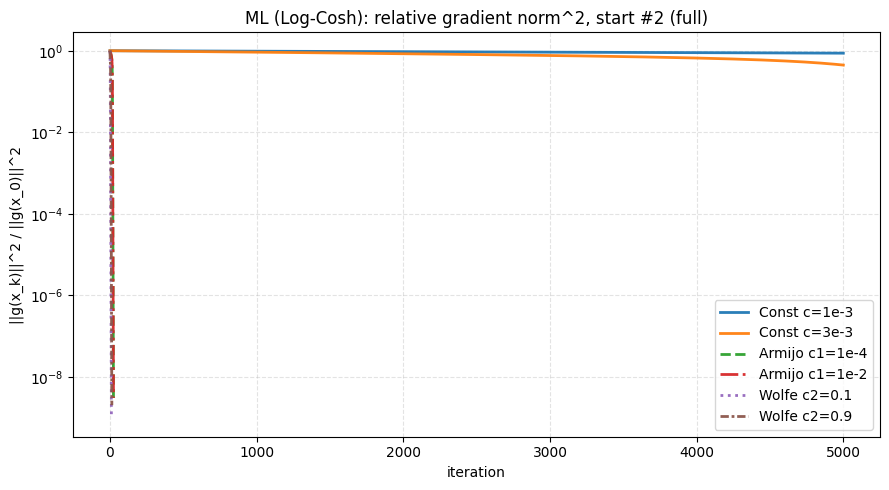

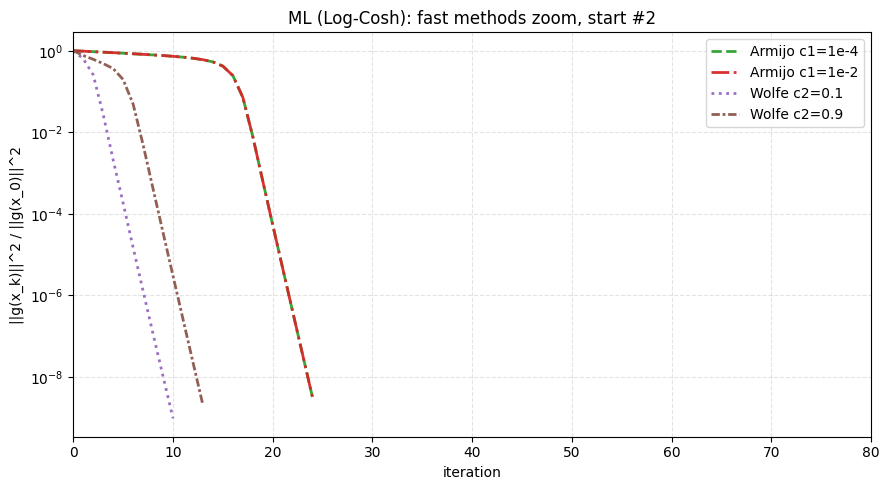

  Best by threshold 1e-8: Wolfe c2=0.1, iter=10
--------------------------------------------------------------------------------


In [ ]:
# ----- 2) ML oracle (Log-Cosh + L2) -----

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

m, n = 1200, 40
X = np.random.randn(m, n)
w_true = np.random.randn(n)
noise = 0.2 * np.random.randn(m)
y = X @ w_true + noise

regcoef = 1e-2

matvec_Ax = lambda x: X @ x
matvec_ATx = lambda x: X.T @ x
matmat_ATsA = lambda s: X.T @ (s[:, None] * X)

ml_oracle = LogCoshL2Oracle(matvec_Ax, matvec_ATx, matmat_ATsA, y, regcoef)

x0_ml_variants = [
    np.zeros(n),
    2.0 * np.ones(n),
]

ml_strategies = {
    "Const c=1e-3":   {"method": "Constant", "c": 1e-3},
    "Const c=3e-3":   {"method": "Constant", "c": 3e-3},
    "Armijo c1=1e-4": {"method": "Armijo", "c1": 1e-4, "alpha_0": 1.0},
    "Armijo c1=1e-2": {"method": "Armijo", "c1": 1e-2, "alpha_0": 1.0},
    "Wolfe c2=0.1":   {"method": "Wolfe", "c1": 1e-4, "c2": 0.1},
    "Wolfe c2=0.9":   {"method": "Wolfe", "c1": 1e-4, "c2": 0.9},
}

style = {
    "Const c=1e-3":   dict(color="C0", ls="-"),
    "Const c=3e-3":   dict(color="C1", ls="-"),
    "Armijo c1=1e-4": dict(color="C2", ls="--"),
    "Armijo c1=1e-2": dict(color="C3", ls="-."),
    "Wolfe c2=0.1":   dict(color="C4", ls=":"),
    "Wolfe c2=0.9":   dict(color="C5", ls=(0, (3, 1, 1, 1))),
}

def rel_grad_sq(history):
    g = np.asarray(history["grad_norm"], dtype=float)
    g0_sq = max(g[0] ** 2, 1e-32)
    y = (g ** 2) / g0_sq
    y[~np.isfinite(y)] = np.nan
    return y

def first_hit(y, thr=1e-8):
    idx = np.where(np.asarray(y) <= thr)[0]
    return int(idx[0]) if len(idx) else np.inf

for start_id, x0 in enumerate(x0_ml_variants, 1):
    curves = {}
    stats = []

    print(f"ML (Log-Cosh) | start #{start_id}")
    for name, ls_opts in ml_strategies.items():
        x_star, msg, hist = run_gd(
            ml_oracle, x0, ls_opts, tolerance=1e-8, max_iter=5000
        )
        y_curve = rel_grad_sq(hist)
        curves[name] = y_curve
        iters = len(hist["grad_norm"]) - 1
        hit = first_hit(y_curve, thr=1e-8)
        stats.append((name, msg, iters, hit))
        print(f"  {name:16s} msg={msg:22s} iters={iters:5d}, hit@1e-8={hit}")

    # --- Figure 1: full range ---
    plt.figure(figsize=(9, 5))
    for name, y_curve in curves.items():
        st = style[name]
        plt.semilogy(
            np.arange(len(y_curve)),
            np.maximum(y_curve, 1e-16),
            label=name,
            linewidth=2,
            color=st["color"],
            linestyle=st["ls"],
            alpha=0.95,
        )
    plt.title(f"ML (Log-Cosh): relative gradient norm^2, start #{start_id} (full)")
    plt.xlabel("iteration")
    plt.ylabel(r"||g(x_k)||^2 / ||g(x_0)||^2")
    plt.grid(True, which="both", ls="--", alpha=0.35)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Figure 2: zoom on fast methods ---
    fast_names = [k for k in curves if not k.startswith("Const")]
    plt.figure(figsize=(9, 5))
    for name in fast_names:
        y_curve = curves[name]
        st = style[name]
        plt.semilogy(
            np.arange(len(y_curve)),
            np.maximum(y_curve, 1e-16),
            label=name,
            linewidth=2,
            color=st["color"],
            linestyle=st["ls"],
            alpha=0.95,
        )
    plt.xlim(0, 80)
    plt.title(f"ML (Log-Cosh): fast methods zoom, start #{start_id}")
    plt.xlabel("iteration")
    plt.ylabel(r"||g(x_k)||^2 / ||g(x_0)||^2")
    plt.grid(True, which="both", ls="--", alpha=0.35)
    plt.legend()
    plt.tight_layout()
    plt.show()

    finite_hits = [(name, hit) for name, _, _, hit in stats if np.isfinite(hit)]
    if finite_hits:
        best_name, best_iter = min(finite_hits, key=lambda z: z[1])
        print(f"  Best by threshold 1e-8: {best_name}, iter={best_iter}")
    else:
        print("  Best by threshold 1e-8: none reached")
    print("-" * 80)